# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



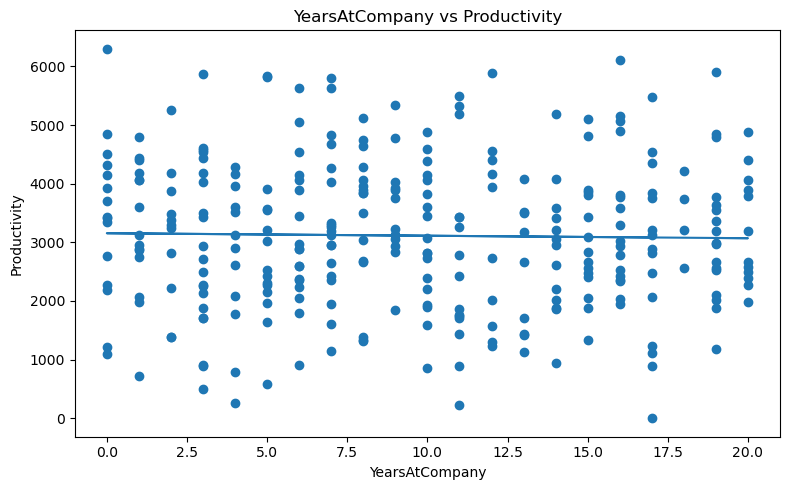

YearsAtCompany R-squared: 0.0


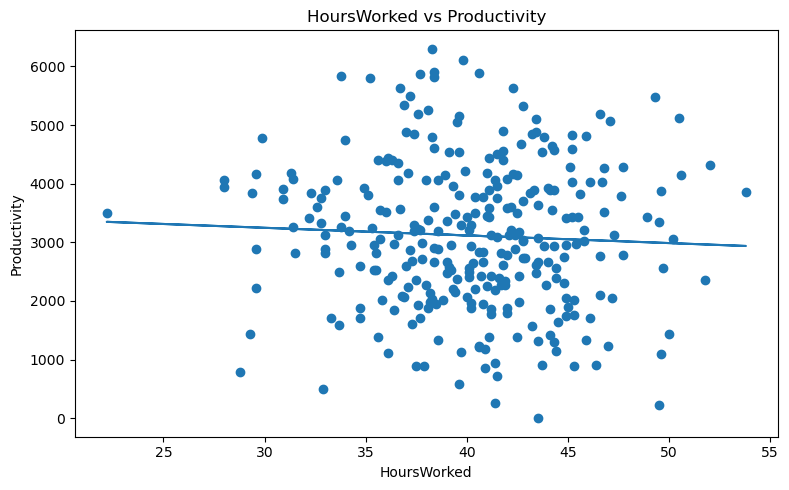

HoursWorked R-squared: 0.003


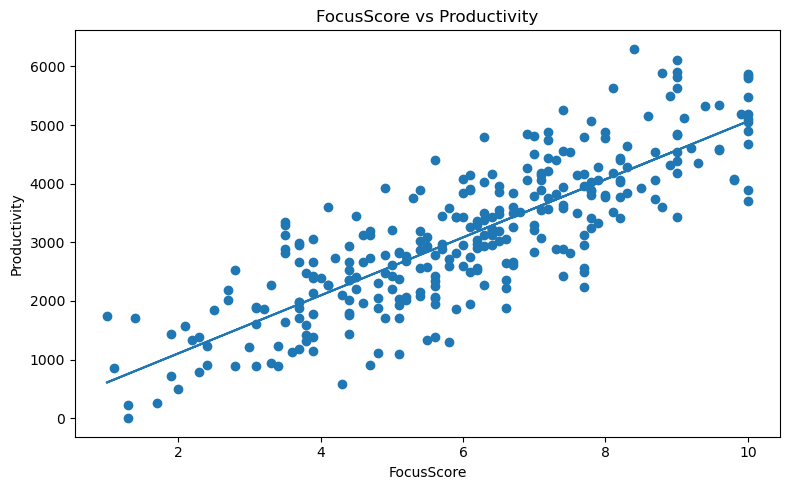

FocusScore R-squared: 0.678


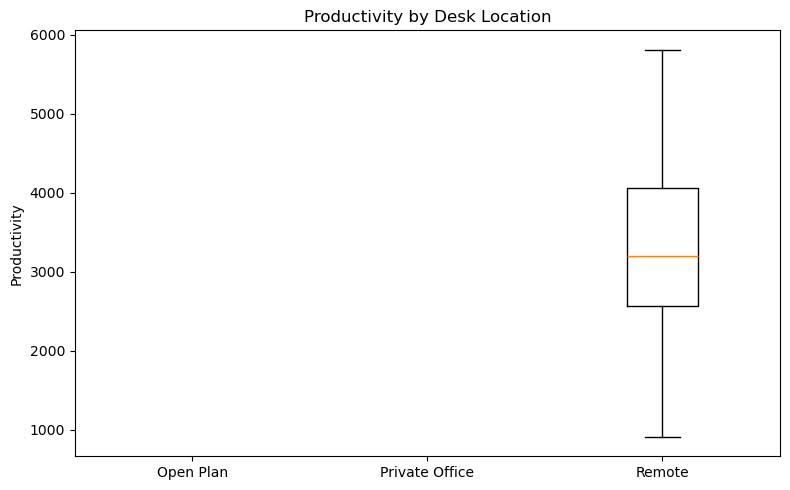

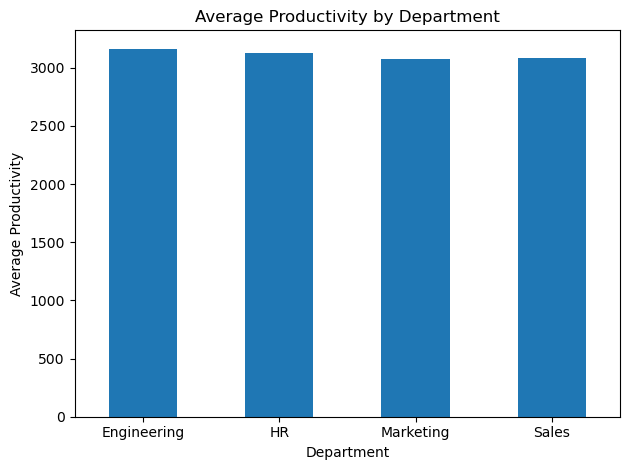

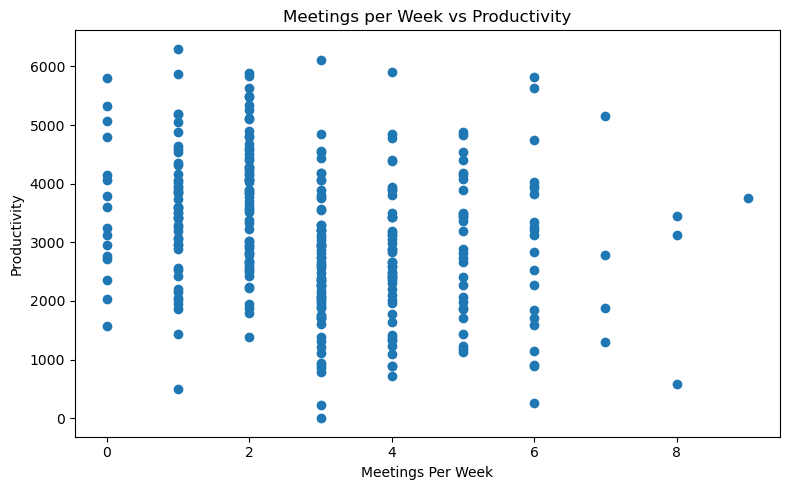

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('Employee_productivity.csv')

# compare features
features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']

for feature in features:

    X = df[[feature]]
    y = df['ProductivityScore']

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)
    r2 = r2_score(y, predictions)

    # graph
    plt.figure(figsize=(8, 5))
    plt.scatter(df[feature], y)
    plt.plot(df[feature], predictions)
    plt.title(f'{feature} vs Productivity')
    plt.xlabel(feature)
    plt.ylabel('Productivity')
    plt.tight_layout()
    plt.show()

    print(feature, 'R-squared:', round(r2, 3))


# meetings
plt.figure(figsize=(8, 5))
plt.boxplot([
    df[df['DeskLocation'] == 'OpenPlan']['ProductivityScore'],
    df[df['DeskLocation'] == 'PrivateOffice']['ProductivityScore'],
    df[df['DeskLocation'] == 'Remote']['ProductivityScore']
], tick_labels=['Open Plan', 'Private Office', 'Remote'])

plt.title('Productivity by Desk Location')
plt.ylabel('Productivity')
plt.tight_layout()
plt.show()


# department
df.groupby('Department')['ProductivityScore'].mean().plot(kind='bar')

plt.title('Average Productivity by Department')
plt.xlabel('Department')
plt.ylabel('Average Productivity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# meetings per week
plt.figure(figsize=(8, 5))
plt.scatter(df['TeamMeetingsPerWeek'], df['ProductivityScore'])

plt.title('Meetings per Week vs Productivity')
plt.xlabel('Meetings Per Week')
plt.ylabel('Productivity')
plt.tight_layout()
plt.show()

In [ ]:
# EMPLOYEE PRODUCTIVITY ANALYSIS — WRITTEN RESPONSE

# Focus Score had the strongest relationship with productivity because the scatterplot showed a clear positive trend and the highest R-squared value out of the three main features. 
# Hours Worked and Years At Company both had weak relationships with productivity since their graphs showed much more scatter and lower R-squared values. 
# Meetings Per Week also appeared to lower productivity because employees with more meetings generally had lower productivity scores.
# Desk Location mattered too since employees working remotely or in private offices tended to be more productive than employees in open plan areas.
# Department showed some differences in average productivity but not as strongly as focus score.
# Overall the model suggests productivity is affected more by focus and work environment than by seniority or simply working longer hours.
# The company should reduce unnecessary meetings, improve quieter workspaces, and give employees more flexibility to help improve both productivity and morale.